In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    SpectralClustering,
    DBSCAN
)

from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../outputs/soil_features_scaled.csv")
df.head()

,taw,organic_carbon,cec,ph,sand_pct,lat,lon,texture_class
0,1.474726,-1.910414,0.164547,2.368321,1.222510,7.323213,80.125184,Loamy sand
1,1.605418,-1.924883,0.163914,2.370244,1.206451,7.323213,80.134612,Loamy sand
2,-0.594931,-1.328773,0.143537,2.250122,1.658271,7.313786,80.002622,Loamy sand
3,-0.515371,-1.336697,0.143093,2.237952,1.621037,7.313786,80.012050,Loamy sand
4,-0.434370,-1.344749,0.142641,2.227331,1.585134,7.313786,80.021478,Loamy sand


In [3]:
CLUSTER_FEATURES = [
    "taw",
    "organic_carbon",
    "cec",
    "ph",
    "sand_pct"
]

X = df[CLUSTER_FEATURES].values
print("Feature matrix shape:", X.shape)

Feature matrix shape: (3422, 5)


In [4]:
def evaluate_clustering(X, labels):
    return {
        "silhouette": silhouette_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels)
    }

In [5]:
kmeans_results = []

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    kmeans_results.append({
        "model": "KMeans",
        "k": k,
        **metrics
    })

kmeans_df = pd.DataFrame(kmeans_results)
kmeans_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,KMeans,2,0.376670,1934.772838,1.152724
1,KMeans,3,0.470120,2602.868202,0.910918
2,KMeans,4,0.510569,2796.242839,0.722892
3,KMeans,5,0.462284,2765.675062,0.765861
4,KMeans,6,0.426108,2863.890241,0.853004
5,KMeans,7,0.417926,2912.353260,0.863344
6,KMeans,8,0.415294,2805.962733,0.853221


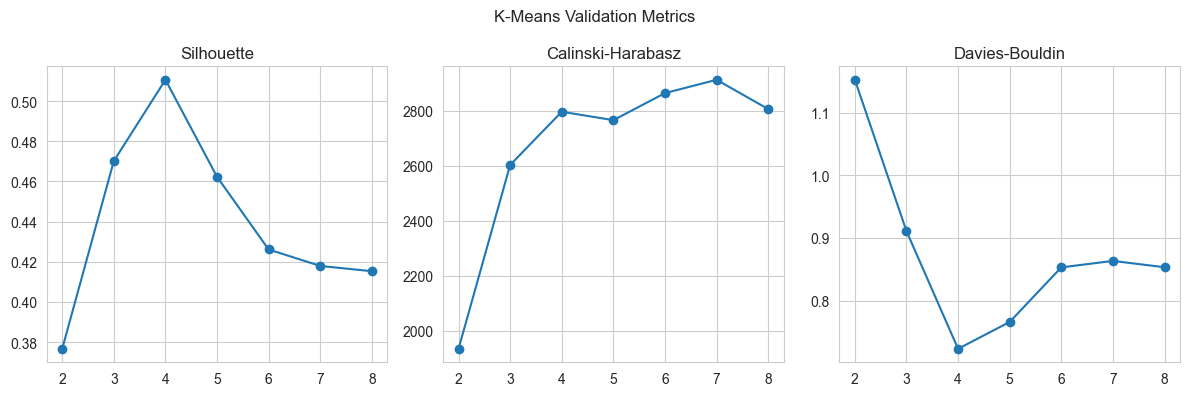

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(kmeans_df.k, kmeans_df.silhouette, marker="o")
plt.title("Silhouette")

plt.subplot(1, 3, 2)
plt.plot(kmeans_df.k, kmeans_df.calinski_harabasz, marker="o")
plt.title("Calinski-Harabasz")

plt.subplot(1, 3, 3)
plt.plot(kmeans_df.k, kmeans_df.davies_bouldin, marker="o")
plt.title("Davies-Bouldin")

plt.suptitle("K-Means Validation Metrics")
plt.tight_layout()
plt.show()

The plots suggest that $k=4$ clusters is the best choice overall for this K-Means run.

**Silhouette score:**\
The Silhouette score increases from $k=2$ to $k=4$, reaching its maximum at $k=4$, then steadily decreases for higher $k$.
This indicates that cluster cohesion and separation are best when using 4 clusters.

**Calinski–Harabasz index:**\
The Calinski–Harabasz index rises sharply from $k=2$ to $k=4$, dips slightly at $k=5$, then peaks at $k=7$ before dropping at $k=8$.
Values at $k=4$ and $k=7$ are both high, but combined with the other metrics, $k=4$ appears more reliable.

**Davies–Bouldin index:**\
The Davies–Bouldin index, where lower is better, decreases from $k=2$ and reaches its minimum at $k=4$, then increases again for larger $k$.
This further supports 4 clusters as giving the most compact and well-separated clustering in this range of $k$.


In [7]:
mbk_results = []

for k in range(2, 9):
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1000
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    mbk_results.append({
        "model": "MiniBatchKMeans",
        "k": k,
        **metrics
    })

mbk_df = pd.DataFrame(mbk_results)
mbk_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,MiniBatchKMeans,2,0.295083,1480.173036,1.388459
1,MiniBatchKMeans,3,0.468944,2599.037483,0.896726
2,MiniBatchKMeans,4,0.510574,2796.202503,0.723468
3,MiniBatchKMeans,5,0.462811,2764.174846,0.762715
4,MiniBatchKMeans,6,0.388480,2589.422743,0.889643
5,MiniBatchKMeans,7,0.411558,2808.096960,0.872094
6,MiniBatchKMeans,8,0.350407,2316.223442,1.032438


The metrics suggest that $k=4$ is the most reasonable choice among the tested values.

**Overall pattern:**\
As $k$ increases from 2 to 4, the silhouette and Calinski–Harabasz scores improve markedly, while the Davies–Bouldin score decreases, indicating better clustering quality.
Beyond $k=4$, silhouette steadily drops and Davies–Bouldin generally increases, which means added clusters are not improving separation or compactness.

**Silhouette observations:**\
Silhouette peaks at $k=4$ with 0.5106, clearly higher than all other $k$ values (next best is $k=3$ with 0.4689).
The decline after $k=4$ (down to 0.3504 at $k=8$) shows clusters become less well-separated and more overlapping as more clusters are added.

**Calinski–Harabasz observations:**\
Calinski–Harabasz is high at $k=4$ (2796.20) and also slightly higher at $k=7$ (2808.10).
Since this index rewards well-separated, compact clusters, both 4 and 7 look good, but must be judged together with the other two metrics.

**Davies–Bouldin observations:**\
Davies–Bouldin, where lower is better, reaches its minimum at $k=4$ (0.7235).
It increases for $k≥5$ and is much worse for $k=2$ and $k=8$ (1.3885 and 1.0324), suggesting those clusterings are relatively poor.

**Practical conclusion:**\
$k=4$ simultaneously maximizes silhouette, minimizes Davies–Bouldin, and gives a near-maximum Calinski–Harabasz, making it the best trade-off between compactness and separation for this MiniBatchKMeans run.

In [8]:
agg_results = []

for k in range(2, 9):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    agg_results.append({
        "model": "Agglomerative",
        "k": k,
        **metrics
    })

agg_df = pd.DataFrame(agg_results)
agg_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,Agglomerative,2,0.360052,1746.597851,1.187616
1,Agglomerative,3,0.458792,2284.980525,0.962337
2,Agglomerative,4,0.493132,2476.083341,0.723227
3,Agglomerative,5,0.459998,2572.859955,0.838890
4,Agglomerative,6,0.419649,2772.346549,0.872608
5,Agglomerative,7,0.396890,2694.399712,0.892569
6,Agglomerative,8,0.402067,2661.743643,0.859876


$k=4$ emerges as the optimal number of clusters for this Agglomerative clustering run, aligning with peaks in silhouette and Calinski–Harabasz scores alongside a minimum in Davies–Bouldin.

**Silhouette Analysis:**\
Silhouette score, measuring cluster cohesion and separation, rises from 0.360 at $k=2$ to a peak of 0.493 at $k=4$, then declines to 0.402 at $k=8$.
This pattern indicates k=4 yields the most distinct and well-defined clusters.

**Calinski–Harabasz Analysis:**\
Calinski–Harabasz index, favoring compact and separated clusters, steadily increases from 1746.6 at $k=2$ to 2772.3 at $k=6$, with $k=4$ at 2476.1 showing strong performance early on.
Higher values at $k=5–6$ suggest good variance ratios, but must balance with other metrics.

**Davies–Bouldin Analysis:**\
Davies–Bouldin index (lower is better) drops sharply to its minimum of 0.723 at $k=4$ from 1.188 at $k=2$, then rises to around 0.86–0.89 for $k=5–8$.
This confirms $k=4$ minimizes similarity between clusters.

**Cross-Metric Consensus:**\
All three metrics converge favorably at $k=4$. Highest silhouette, low Davies–Bouldin, and solid Calinski–Harabasz—consistent with prior MiniBatchKMeans results favoring the same $k$.
Beyond $k=4$, diminishing returns appear as silhouette falls and Davies–Bouldin worsens, signaling overfitting.

In [9]:
gmm_results = []

for k in range(2, 9):
    model = GaussianMixture(
        n_components=k,
        random_state=42
    )
    labels = model.fit_predict(X)
    metrics = evaluate_clustering(X, labels)

    gmm_results.append({
        "model": "GMM",
        "k": k,
        **metrics
    })

gmm_df = pd.DataFrame(gmm_results)
gmm_df

,model,k,silhouette,calinski_harabasz,davies_bouldin
0,GMM,2,0.367669,1682.780681,1.260967
1,GMM,3,0.469927,2500.856919,0.963616
2,GMM,4,0.501309,2650.090546,0.732842
3,GMM,5,0.396917,2331.377831,1.064862
4,GMM,6,0.444993,2314.340715,0.824386
5,GMM,7,0.399644,2060.011934,0.903752
6,GMM,8,0.351800,2334.832478,0.945376


$k=4$ stands out as the optimal number of clusters for this GMM run, showing the strongest consensus across all three metrics.

**Silhouette Score:**\
Silhouette peaks sharply at $k=4$ (0.5013), surpassing $k=3$ (0.4699) and dropping notably at $k=5$ (0.3969).
This confirms excellent cluster cohesion and separation specifically at 4 components.

**Calinski–Harabasz Index:**\
The index climbs steadily to 2650.09 at $k=4$, then declines overall (lowest at $k=7$ with 2060.01).
$k=4$ balances high variance explanation with compact clusters effectively.

**Davies–Bouldin Index:**\
Davies–Bouldin reaches its minimum (best) at $k=4$ (0.7328), improving from $k=3$ (0.9636) and worsening afterward.
Lower values here indicate minimal intra-cluster scatter relative to inter-cluster distances.

**Model Consensus:**\
GMM reinforces the $k=4$ preference seen in prior MiniBatchKMeans and Agglomerative results, with silhouette at its highest (0.5013 vs. 0.5106 and 0.4931 previously).
This cross-model agreement strengthens confidence in 4 clusters for the dataset.